**CNN-BASED ROAD SURFACE DAMAGE DETECTION**


**MACHINE VISION PROJECT**\
Mihika Manish 23BAI0210\
Daksh Goel 23BAI0220

A custom CNN trained from scratch to classify road surface images into 4 severity levels —Good, Satisfactory, Poor, and Very Poor — with confidence scoring, severity index computation and location-based priority alert generation and Grad CAM Explainations.

Section 1: Environment Setup

In [2]:
# Install kagglehub to download datasets directly
!pip install kagglehub -q

Section 2 — Dataset Download & Configuration

In [3]:
# Standard libraries for file handling, randomness, timing and warnings
import os, random, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import kagglehub
import cv2

# PyTorch core libraries for building and training the CNN
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler, Dataset
from torchvision import datasets, transforms

# Scikit-learn for evaluation metrics and dataset splitting
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_fscore_support)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Set seeds for reproducibility across all libraries
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Use GPU if available, otherwise fall back to CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
# Download the road damage dataset directly from Kaggle using kagglehub
path = kagglehub.dataset_download("prudhvignv/road-damage-classification-and-assessment")
print("Downloaded to:", path)

# Walk through the downloaded folder to find where the 4 class subfolders are
DATASET_ROOT = None
for root, dirs, files in os.walk(path):
    if set(['good', 'poor', 'satisfactory', 'very_poor']).issubset(set(dirs)):
        DATASET_ROOT = root
        break

assert DATASET_ROOT is not None, "Could not find class folders!"
print("Dataset root:", DATASET_ROOT)
print("Classes found:", os.listdir(DATASET_ROOT))

Using Colab cache for faster access to the 'road-damage-classification-and-assessment' dataset.
Downloaded to: /kaggle/input/road-damage-classification-and-assessment
Dataset root: /kaggle/input/road-damage-classification-and-assessment/sih_road_dataset
Classes found: ['good', 'very_poor', 'poor', 'satisfactory']


In [5]:
# Central config dictionary so all hyperparameters are in one place
CFG = {
    'img_size'       : 224,   # resize all images to 224x224 for the CNN input
    'batch_size'     : 32,    # number of images processed per training step
    'num_epochs'     : 30,    # maximum training epochs
    'lr'             : 1e-3,  # initial learning rate for AdamW
    'weight_decay'   : 1e-4,  # L2 regularization to reduce overfitting
    'dropout'        : 0.5,   # dropout probability in the classifier head
    'val_split'      : 0.15,  # fraction of data used for validation
    'test_split'     : 0.15,  # fraction of data held out for final testing
    'num_workers'    : 2,     # parallel workers for data loading
    'patience'       : 7,     # early stopping patience in epochs
    'label_smoothing': 0.05,  # softens hard labels to improve generalization
}

# Class names must match the folder names in the dataset
CLASS_NAMES      = ['good', 'poor', 'satisfactory', 'very_poor']
NUM_CLASSES      = len(CLASS_NAMES)

# Severity weights reflect how dangerous each class is for road users
# good=0 (no risk), poor=2, satisfactory=1, very_poor=3 (highest risk)
SEVERITY_WEIGHTS = torch.tensor([0.0, 2.0, 1.0, 3.0], dtype=torch.float32)

print('Classes:', CLASS_NAMES)
print('Config:', CFG)

Classes: ['good', 'poor', 'satisfactory', 'very_poor']
Config: {'img_size': 224, 'batch_size': 32, 'num_epochs': 30, 'lr': 0.001, 'weight_decay': 0.0001, 'dropout': 0.5, 'val_split': 0.15, 'test_split': 0.15, 'num_workers': 2, 'patience': 7, 'label_smoothing': 0.05}


Section 3 — Image Preprocessing Pipeline

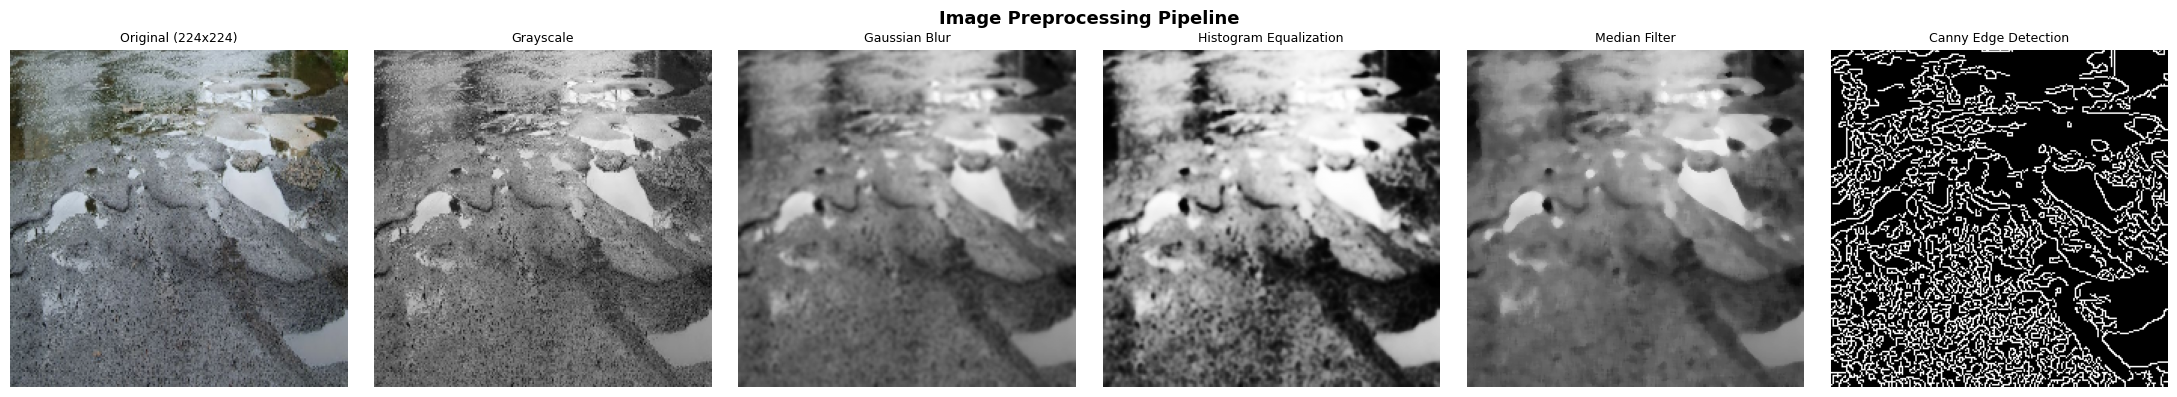

In [6]:
# This function demonstrates the image preprocessing pipeline step by step
# Each stage prepares the image for better feature extraction by the CNN
def show_preprocessing_pipeline(image_path):

    # Read the image and convert from BGR (OpenCV default) to RGB
    img_bgr     = cv2.imread(image_path)
    img_rgb     = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Resize to 224x224 which is the standard input size for our CNN
    img_resized = cv2.resize(img_rgb, (224, 224))

    # Convert to grayscale to remove color information and focus on texture
    gray        = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)

    # Apply Gaussian blur to reduce noise while preserving edges
    blurred     = cv2.GaussianBlur(gray, (5, 5), 0)

    # Histogram equalization spreads intensity values to improve contrast
    equalized   = cv2.equalizeHist(blurred)

    # Median filter removes salt and pepper noise while keeping edges sharp
    median      = cv2.medianBlur(gray, 5)

    # Canny edge detection highlights structural damage boundaries on the road
    edges       = cv2.Canny(equalized, 50, 150)

    stages = [
        (img_resized, 'Original (224x224)'),
        (gray,        'Grayscale'),
        (blurred,     'Gaussian Blur'),
        (equalized,   'Histogram Equalization'),
        (median,      'Median Filter'),
        (edges,       'Canny Edge Detection'),
    ]

    fig, axes = plt.subplots(1, 6, figsize=(22, 4))
    fig.suptitle('Image Preprocessing Pipeline', fontsize=13, fontweight='bold')
    for ax, (img, title) in zip(axes, stages):
        cmap = None if len(img.shape) == 3 else 'gray'
        ax.imshow(img, cmap=cmap)
        ax.set_title(title, fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('/content/preprocessing_pipeline.png', dpi=120, bbox_inches='tight')
    plt.show()

# Pick a sample from the very_poor class to clearly show damage features
vp_dir      = os.path.join(DATASET_ROOT, 'very_poor')
sample_path = os.path.join(vp_dir, os.listdir(vp_dir)[0])
show_preprocessing_pipeline(sample_path)

Section 4 — Dataset Preparation & DataLoaders

In [7]:
# ImageNet mean and std used for normalization since our images are natural photos
IMG_MEAN = [0.485, 0.456, 0.406]
IMG_STD  = [0.229, 0.224, 0.225]

# Training transform applies augmentations to artificially expand the dataset
# This teaches the model to be robust to lighting, orientation and position changes
train_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(p=0.5),       # roads look similar flipped
    transforms.RandomVerticalFlip(p=0.2),         # occasional top-down variation
    transforms.RandomRotation(15),                # handle camera angle variation
    transforms.ColorJitter(brightness=0.3,        # simulate different lighting
                           contrast=0.3,
                           saturation=0.2,
                           hue=0.05),
    transforms.RandomAffine(degrees=0,            # simulate camera position shift
                            translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

# Validation and test transform only resizes and normalizes, no augmentation
val_tf = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(IMG_MEAN, IMG_STD),
])

# Load the full dataset using ImageFolder which reads subfolders as class labels
full_dataset = datasets.ImageFolder(DATASET_ROOT)
targets      = np.array(full_dataset.targets)
indices      = np.arange(len(full_dataset))

# Stratified split ensures each class is proportionally represented in all splits
idx_train, idx_temp = train_test_split(
    indices,
    test_size=CFG['val_split'] + CFG['test_split'],
    stratify=targets,
    random_state=SEED)

idx_val, idx_test = train_test_split(
    idx_temp,
    test_size=CFG['test_split'] / (CFG['val_split'] + CFG['test_split']),
    stratify=targets[idx_temp],
    random_state=SEED)

print(f'Train: {len(idx_train)}  Val: {len(idx_val)}  Test: {len(idx_test)}')

# Custom dataset wrapper that applies different transforms to each split
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset   = dataset
        self.indices   = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        path, label = self.dataset.samples[self.indices[i]]
        img = Image.open(path).convert('RGB')
        return self.transform(img), label

train_ds = TransformSubset(full_dataset, idx_train, train_tf)
val_ds   = TransformSubset(full_dataset, idx_val,   val_tf)
test_ds  = TransformSubset(full_dataset, idx_test,  val_tf)

# Compute per-class weights to counter class imbalance during training
# Classes with fewer samples get higher weight so they are sampled more often
train_labels   = targets[idx_train]
class_counts   = np.bincount(train_labels)
class_weights  = 1.0 / class_counts
sample_weights = torch.tensor([class_weights[l] for l in train_labels],
                               dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# Create data loaders with pin_memory for faster GPU transfer
train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'],
                          sampler=sampler,
                          num_workers=CFG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False,
                          num_workers=CFG['num_workers'], pin_memory=True)

print('Class distribution (train):', dict(zip(CLASS_NAMES, class_counts)))

Train: 1451  Val: 311  Test: 312
Class distribution (train): {'good': np.int64(591), 'poor': np.int64(277), 'satisfactory': np.int64(360), 'very_poor': np.int64(223)}


Section 5 — Sample Visualization


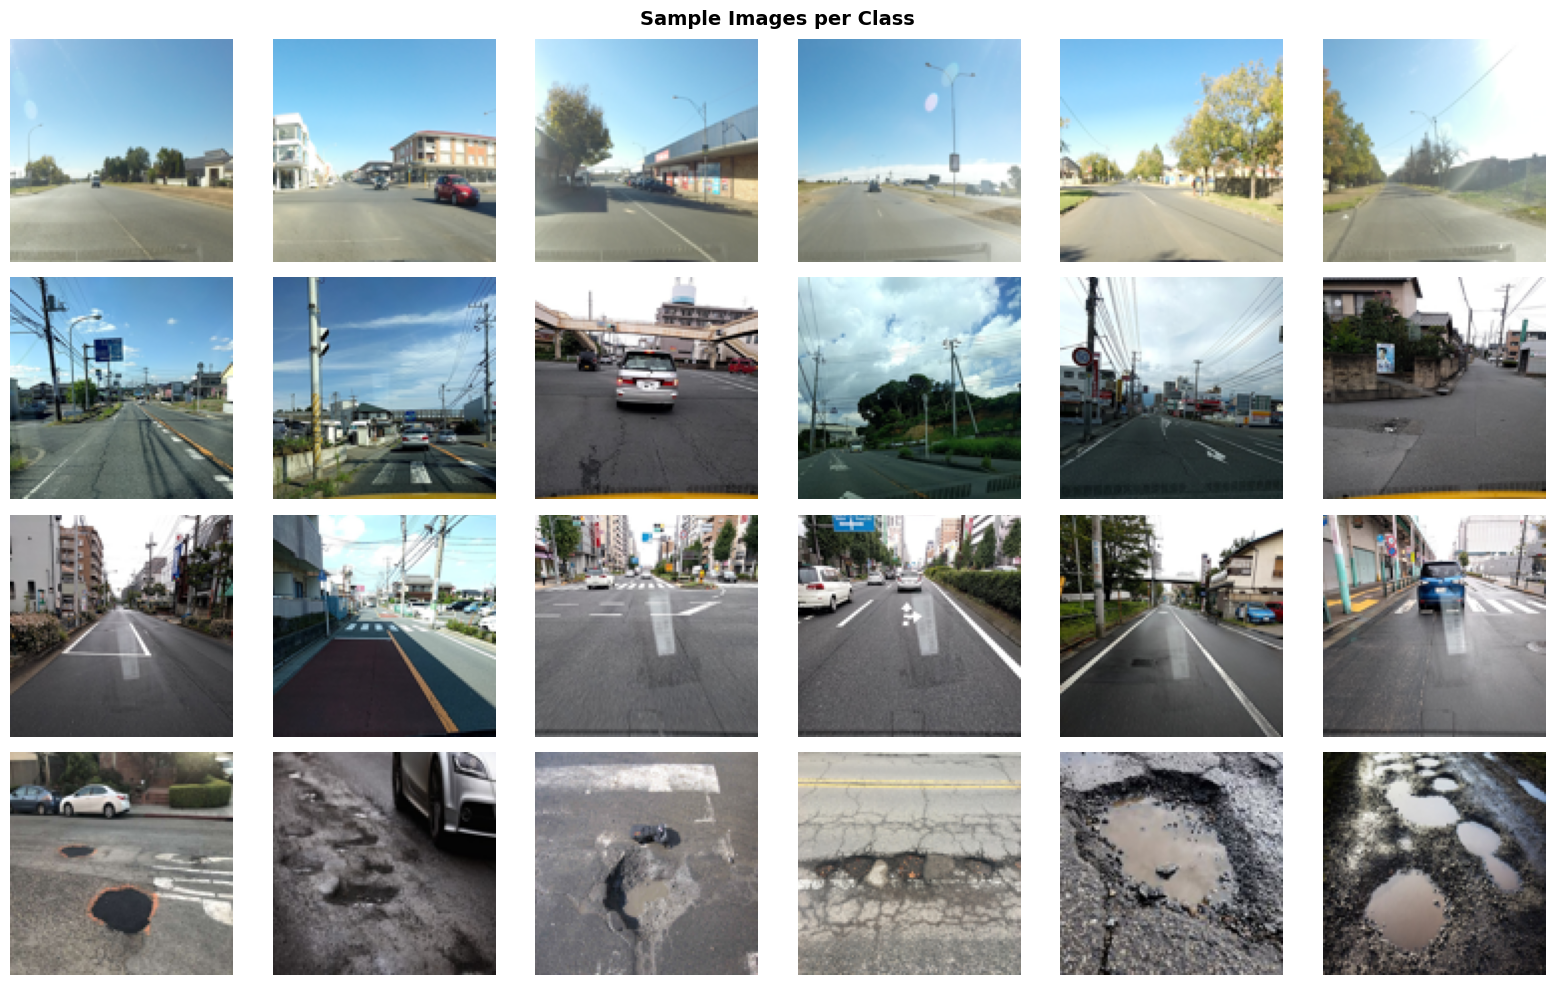

In [8]:
# Helper to reverse the normalization so we can display images correctly
def denormalize(tensor):
    mean = torch.tensor(IMG_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMG_STD).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

# Show 6 random samples from each class to visually understand the dataset
fig, axes = plt.subplots(4, 6, figsize=(16, 10))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_idx     = full_dataset.class_to_idx[cls]
    cls_samples = [i for i, (_, l) in enumerate(full_dataset.samples) if l == cls_idx]
    chosen      = random.sample(cls_samples, min(6, len(cls_samples)))
    for col, idx in enumerate(chosen):
        path, _ = full_dataset.samples[idx]
        img     = Image.open(path).convert('RGB').resize((112, 112))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=11, rotation=0,
                                      labelpad=60, va='center')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

Section 6 — Model Architecture

In [9]:
# ConvBlock stacks two conv layers with batch norm and relu before downsampling
# Using two convolutions per block increases receptive field without extra pooling
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        super().__init__()
        layers = [
            # First conv learns low level features like edges and textures
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),   # normalize activations for stable training
            nn.ReLU(inplace=True),
            # Second conv combines those features into more complex patterns
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            # MaxPool halves the spatial dimensions at each block
            layers.append(nn.MaxPool2d(2, 2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class RoadDamageCNN(nn.Module):
    """
    Custom CNN trained from scratch for road damage severity classification.
    Input  : (B, 3, 224, 224)
    Output : (B, num_classes) logits

    Feature extraction:
        Conv32 (224->112) -> Conv64 (112->56) -> Conv128 (56->28) -> Conv256 (28->14)
        -> extra Conv256 at 14x14 for deeper feature refinement

    Classification head:
        GlobalAvgPool -> FC512 -> Dropout(0.5) -> FC256 -> Dropout(0.3) -> FC(4)
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # Feature extractor progressively increases channels while halving spatial size
        self.features = nn.Sequential(
            ConvBlock(3,   32),    # 224x224 -> 112x112, learns basic edges
            ConvBlock(32,  64),    # 112x112 -> 56x56,  learns textures
            ConvBlock(64,  128),   # 56x56   -> 28x28,  learns crack patterns
            ConvBlock(128, 256),   # 28x28   -> 14x14,  learns damage structures
            # Extra conv at 14x14 to refine high level features without further pooling
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # Global average pooling collapses spatial dims to a single vector per channel
        # This makes the model input-size flexible and reduces overfitting vs Flatten
        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        # Classifier head maps 256 features to class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),         # main dropout to prevent overfitting
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.6),   # lighter dropout in deeper layer
            nn.Linear(256, num_classes),
        )
        self._init_weights()

    def _init_weights(self):
        # Kaiming init for conv layers works well with ReLU activations
        # Xavier init for linear layers balances gradient flow
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)


model = RoadDamageCNN(num_classes=NUM_CLASSES, dropout=CFG['dropout']).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(model)

Total parameters    : 2,027,492
Trainable parameters: 2,027,492
RoadDamageCNN(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stri

Section 7 — Training

In [10]:
# Label smoothing cross entropy prevents overconfident predictions
criterion = nn.CrossEntropyLoss(label_smoothing=CFG['label_smoothing'])

# AdamW combines Adam with proper weight decay decoupled from the gradient update
optimizer = optim.AdamW(model.parameters(),
                        lr=CFG['lr'],
                        weight_decay=CFG['weight_decay'])

# CosineAnnealingLR smoothly reduces the learning rate to near zero over all epochs
# This is more stable than OneCycleLR for custom CNNs trained from scratch
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=CFG['num_epochs'],
    eta_min=1e-6
)

print('Optimizer:', optimizer.__class__.__name__)
print('Scheduler:', scheduler.__class__.__name__)
print('Loss     :', criterion)

Optimizer: AdamW
Scheduler: CosineAnnealingLR
Loss     : CrossEntropyLoss()


In [11]:
# Track metrics each epoch to plot learning curves later
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss'  : [], 'val_acc'  : [],
    'lr'        : []
}

best_val_acc = 0.0
patience_ctr = 0
CKPT_PATH    = '/content/best_model.pth'

def run_epoch(loader, train=True):
    # Switch model to train or eval mode which affects dropout and batch norm behavior
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            if train:
                optimizer.zero_grad()   # clear gradients from previous step

            logits = model(imgs)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()         # compute gradients via backpropagation
                # Gradient clipping prevents exploding gradients during training
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()        # update weights using computed gradients

            total_loss += loss.item() * imgs.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

    # Step the scheduler after each full epoch
    if train:
        scheduler.step()

    return total_loss / total, correct / total


print(f'Training for {CFG["num_epochs"]} epochs on {DEVICE}')
print('-' * 70)

for epoch in range(1, CFG['num_epochs'] + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, train=True)
    vl_loss, vl_acc = run_epoch(val_loader,   train=False)
    elapsed    = time.time() - t0
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['lr'].append(current_lr)

    print(f'Epoch {epoch:3d}/{CFG["num_epochs"]}  '
          f'Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  '
          f'Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  '
          f'LR: {current_lr:.2e}  Time: {elapsed:.1f}s')

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        patience_ctr = 0
        # Save the full checkpoint including optimizer state for potential resumption
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc'        : vl_acc,
            'class_names'    : CLASS_NAMES,
        }, CKPT_PATH)
        print(f'           Checkpoint saved (val_acc={vl_acc:.4f})')
    else:
        patience_ctr += 1
        if patience_ctr >= CFG['patience']:
            print(f'Early stopping triggered at epoch {epoch}')
            break

print('-' * 70)
print(f'Best Val Accuracy: {best_val_acc:.4f}')

Training for 30 epochs on cuda
----------------------------------------------------------------------
Epoch   1/30  Train Loss: 0.8683  Acc: 0.6692  Val Loss: 0.5726  Acc: 0.8264  LR: 9.97e-04  Time: 40.1s
           Checkpoint saved (val_acc=0.8264)
Epoch   2/30  Train Loss: 0.6804  Acc: 0.7877  Val Loss: 0.5202  Acc: 0.8553  LR: 9.89e-04  Time: 39.0s
           Checkpoint saved (val_acc=0.8553)
Epoch   3/30  Train Loss: 0.6510  Acc: 0.8036  Val Loss: 0.5104  Acc: 0.8650  LR: 9.76e-04  Time: 42.5s
           Checkpoint saved (val_acc=0.8650)
Epoch   4/30  Train Loss: 0.5455  Acc: 0.8511  Val Loss: 0.4634  Acc: 0.8746  LR: 9.57e-04  Time: 38.1s
           Checkpoint saved (val_acc=0.8746)
Epoch   5/30  Train Loss: 0.5336  Acc: 0.8663  Val Loss: 0.7756  Acc: 0.7621  LR: 9.33e-04  Time: 40.5s
Epoch   6/30  Train Loss: 0.5365  Acc: 0.8567  Val Loss: 0.5701  Acc: 0.8778  LR: 9.05e-04  Time: 37.3s
           Checkpoint saved (val_acc=0.8778)
Epoch   7/30  Train Loss: 0.4947  Acc: 0.8884  Va

Section 8 — Training Curves


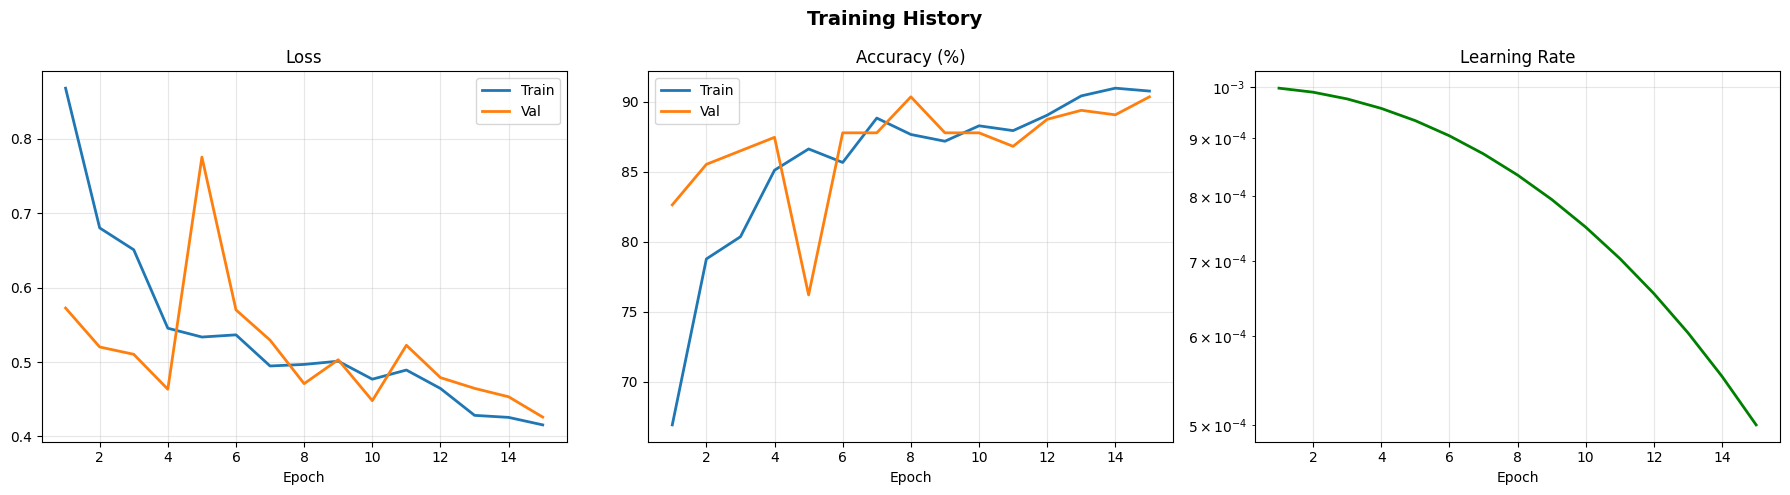

In [12]:
# Plot loss, accuracy and learning rate to check for overfitting or underfitting
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')

axes[0].plot(epochs, history['train_loss'], label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'],   label='Val',   linewidth=2)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a * 100 for a in history['train_acc']], label='Train', linewidth=2)
axes[1].plot(epochs, [a * 100 for a in history['val_acc']],   label='Val',   linewidth=2)
axes[1].set_title('Accuracy (%)')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Log scale on LR plot makes the cosine decay shape visible
axes[2].plot(epochs, history['lr'], color='green', linewidth=2)
axes[2].set_title('Learning Rate')
axes[2].set_xlabel('Epoch')
axes[2].set_yscale('log')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

Section 9 — Evaluation & Results


In [13]:
# Load the best checkpoint saved during training, not the final epoch weights
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state'])
print(f'Loaded checkpoint from epoch {ckpt["epoch"]} (val_acc={ckpt["val_acc"]:.4f})')

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs   = imgs.to(DEVICE)
        logits = model(imgs)
        # Softmax converts raw logits to probabilities that sum to 1
        probs  = F.softmax(logits, dim=1).cpu()
        all_probs.append(probs)
        all_preds.extend(probs.argmax(1).numpy())
        all_labels.extend(labels.numpy())

all_probs  = torch.cat(all_probs, dim=0).numpy()
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = (all_preds == all_labels).mean()
print(f'\nTest Accuracy: {test_acc:.4f} ({test_acc * 100:.2f}%)')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds,
                             target_names=CLASS_NAMES, digits=4))

Loaded checkpoint from epoch 8 (val_acc=0.9035)

Test Accuracy: 0.9263 (92.63%)

Classification Report:
              precision    recall  f1-score   support

        good     0.9695    1.0000    0.9845       127
        poor     0.8824    0.7500    0.8108        60
satisfactory     0.8642    0.8974    0.8805        78
   very_poor     0.9592    1.0000    0.9792        47

    accuracy                         0.9263       312
   macro avg     0.9188    0.9119    0.9137       312
weighted avg     0.9248    0.9263    0.9243       312



Section 10 — Confusion Matrix & Per-Class Metrics

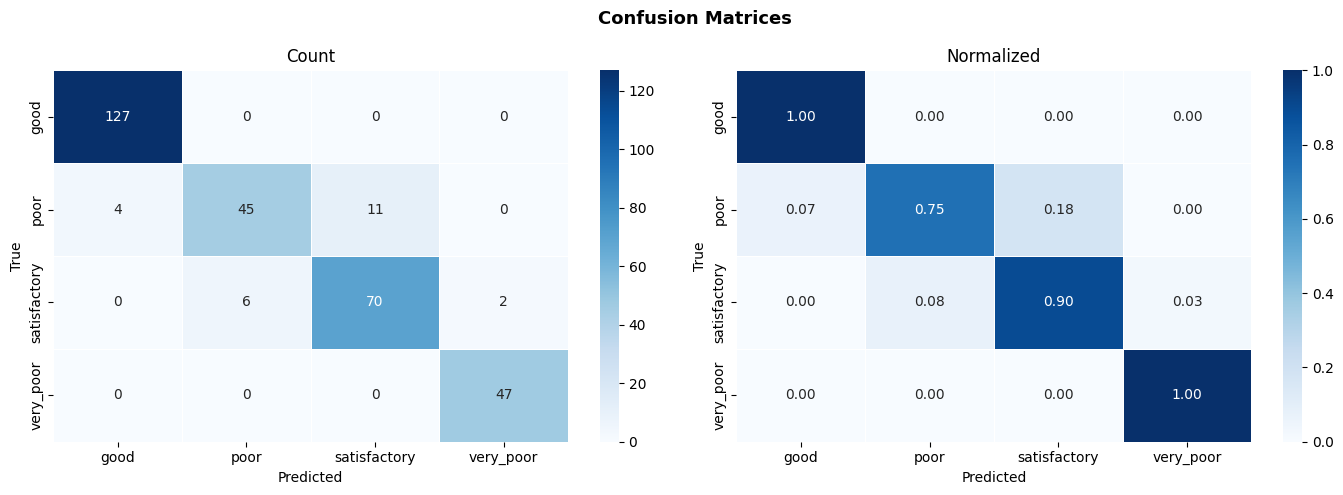

In [14]:
# Confusion matrix shows which classes get confused with each other
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')

for ax, data, fmt, title in zip(
        axes, [cm, cm_norm], ['d', '.2f'], ['Count', 'Normalized']):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

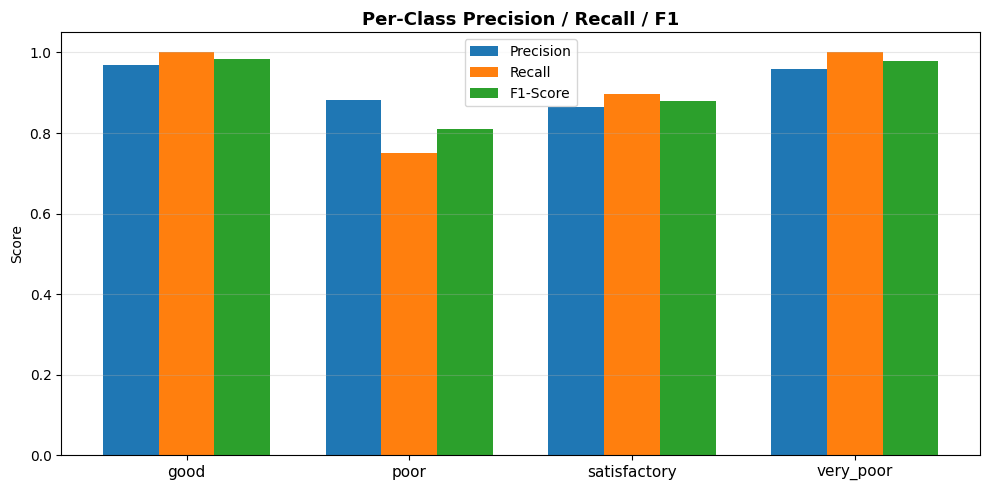

In [15]:
# Precision, recall and F1 per class shows where the model is weakest
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average=None)

x, w = np.arange(NUM_CLASSES), 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - w, precision, w, label='Precision')
ax.bar(x,     recall,    w, label='Recall')
ax.bar(x + w, f1,        w, label='F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/per_class_metrics.png', dpi=120, bbox_inches='tight')
plt.show()

Section 11 — Grad-CAM Visualization

In [16]:
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping (Grad-CAM).

    How it works:
        1. Run a forward pass and get the feature maps at the target conv layer
        2. Run a backward pass for the target class to get gradients at that layer
        3. Global average pool the gradients to get per-channel importance weights
        4. Weighted sum of feature maps gives a heatmap of important regions
        5. ReLU removes negative values since we only care about regions that
           increase the class score, not regions that suppress it

    This shows us exactly which parts of the road image the CNN looks at
    when making its damage severity prediction.
    """
    def __init__(self, model, target_layer):
        self.model        = model
        self.target_layer = target_layer
        self.gradients    = None
        self.activations  = None
        self._register_hooks()

    def _register_hooks(self):
        # Forward hook captures the feature map output at the target layer
        def forward_hook(module, input, output):
            self.activations = output.detach()

        # Backward hook captures the gradients flowing back through the target layer
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(DEVICE).unsqueeze(0)
        input_tensor.requires_grad_()

        # Forward pass to get predictions
        logits = self.model(input_tensor)
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()

        # Backward pass only for the target class score
        self.model.zero_grad()
        logits[0, class_idx].backward()

        # Average gradients across spatial dimensions to get channel importance
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Weighted combination of forward activation maps
        cam = (weights * self.activations).sum(dim=1).squeeze(0)

        # ReLU keeps only regions that positively influence the prediction
        cam = F.relu(cam)

        # Normalize to 0-1 range for visualization
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx


# Hook Grad-CAM to the last conv layer which captures the most semantic features
# index -3 is the Conv2d before the final BatchNorm and ReLU in self.features
target_layer = model.features[-3]
gradcam      = GradCAM(model, target_layer)
print("Grad-CAM attached to:", target_layer)

Grad-CAM attached to: Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)


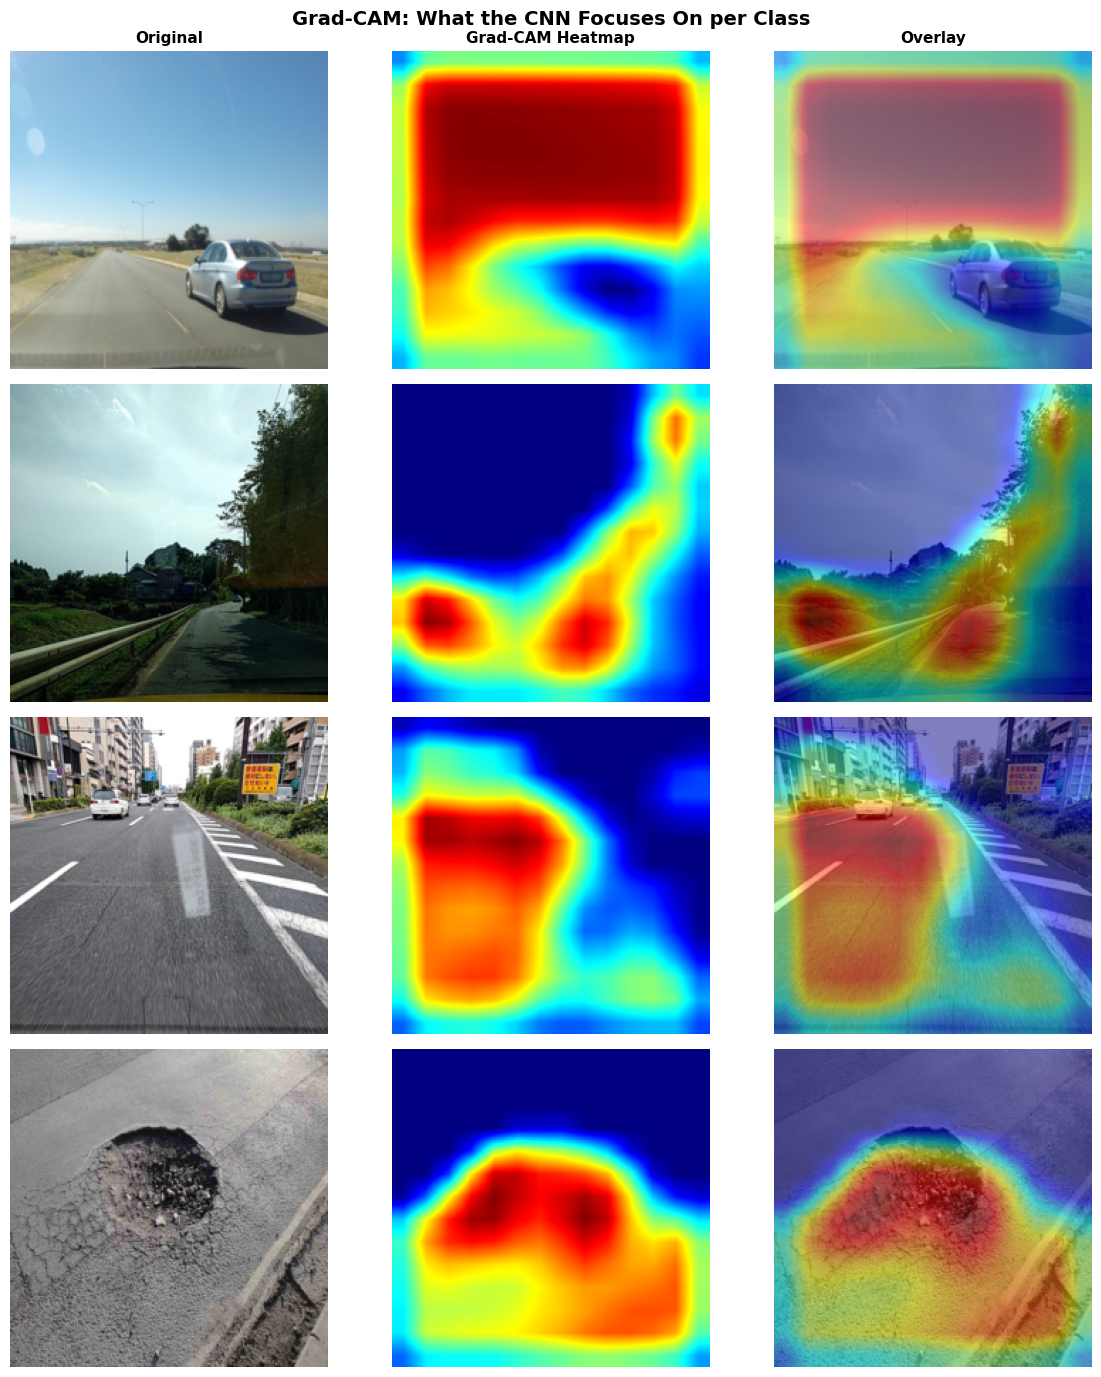

In [17]:
# Helper that resizes the CAM and blends it with the original image
def overlay_gradcam(img_tensor, cam, alpha=0.5):
    img_np      = denormalize(img_tensor).permute(1, 2, 0).numpy()
    cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
    # Apply JET colormap so high activation areas appear red and low areas blue
    heatmap     = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap     = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
    # Blend heatmap with original image using alpha transparency
    overlaid    = alpha * heatmap + (1 - alpha) * img_np
    return np.clip(overlaid, 0, 1), img_np


# Show Grad-CAM for one correctly classified sample from each class
# Correct samples are chosen so we see what the model learned when it works well
fig, axes = plt.subplots(NUM_CLASSES, 3, figsize=(12, 14))
fig.suptitle('Grad-CAM: What the CNN Focuses On per Class',
             fontsize=14, fontweight='bold')

for ax, t in zip(axes[0], ['Original', 'Grad-CAM Heatmap', 'Overlay']):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_idx = full_dataset.class_to_idx[cls]

    # Prefer correctly classified samples for clean visualization
    correct_idxs = [i for i in range(len(idx_test))
                    if all_labels[i] == cls_idx and all_preds[i] == cls_idx]
    if not correct_idxs:
        correct_idxs = [i for i in range(len(idx_test)) if all_labels[i] == cls_idx]

    pick       = random.choice(correct_idxs)
    img_tensor, _ = test_ds[pick]

    # Generate CAM for the true class of this sample
    cam, _ = gradcam.generate(img_tensor, class_idx=cls_idx)
    overlay, orig = overlay_gradcam(img_tensor, cam)

    heatmap_vis = cv2.resize(cam, (224, 224))
    heatmap_rgb = cv2.applyColorMap(np.uint8(255 * heatmap_vis), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(orig)
    axes[row][0].set_ylabel(cls, fontsize=10, rotation=0, labelpad=65, va='center')
    axes[row][1].imshow(heatmap_rgb)
    axes[row][2].imshow(overlay)

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_per_class.png', dpi=120, bbox_inches='tight')
plt.show()

Misclassified: 23 / 312


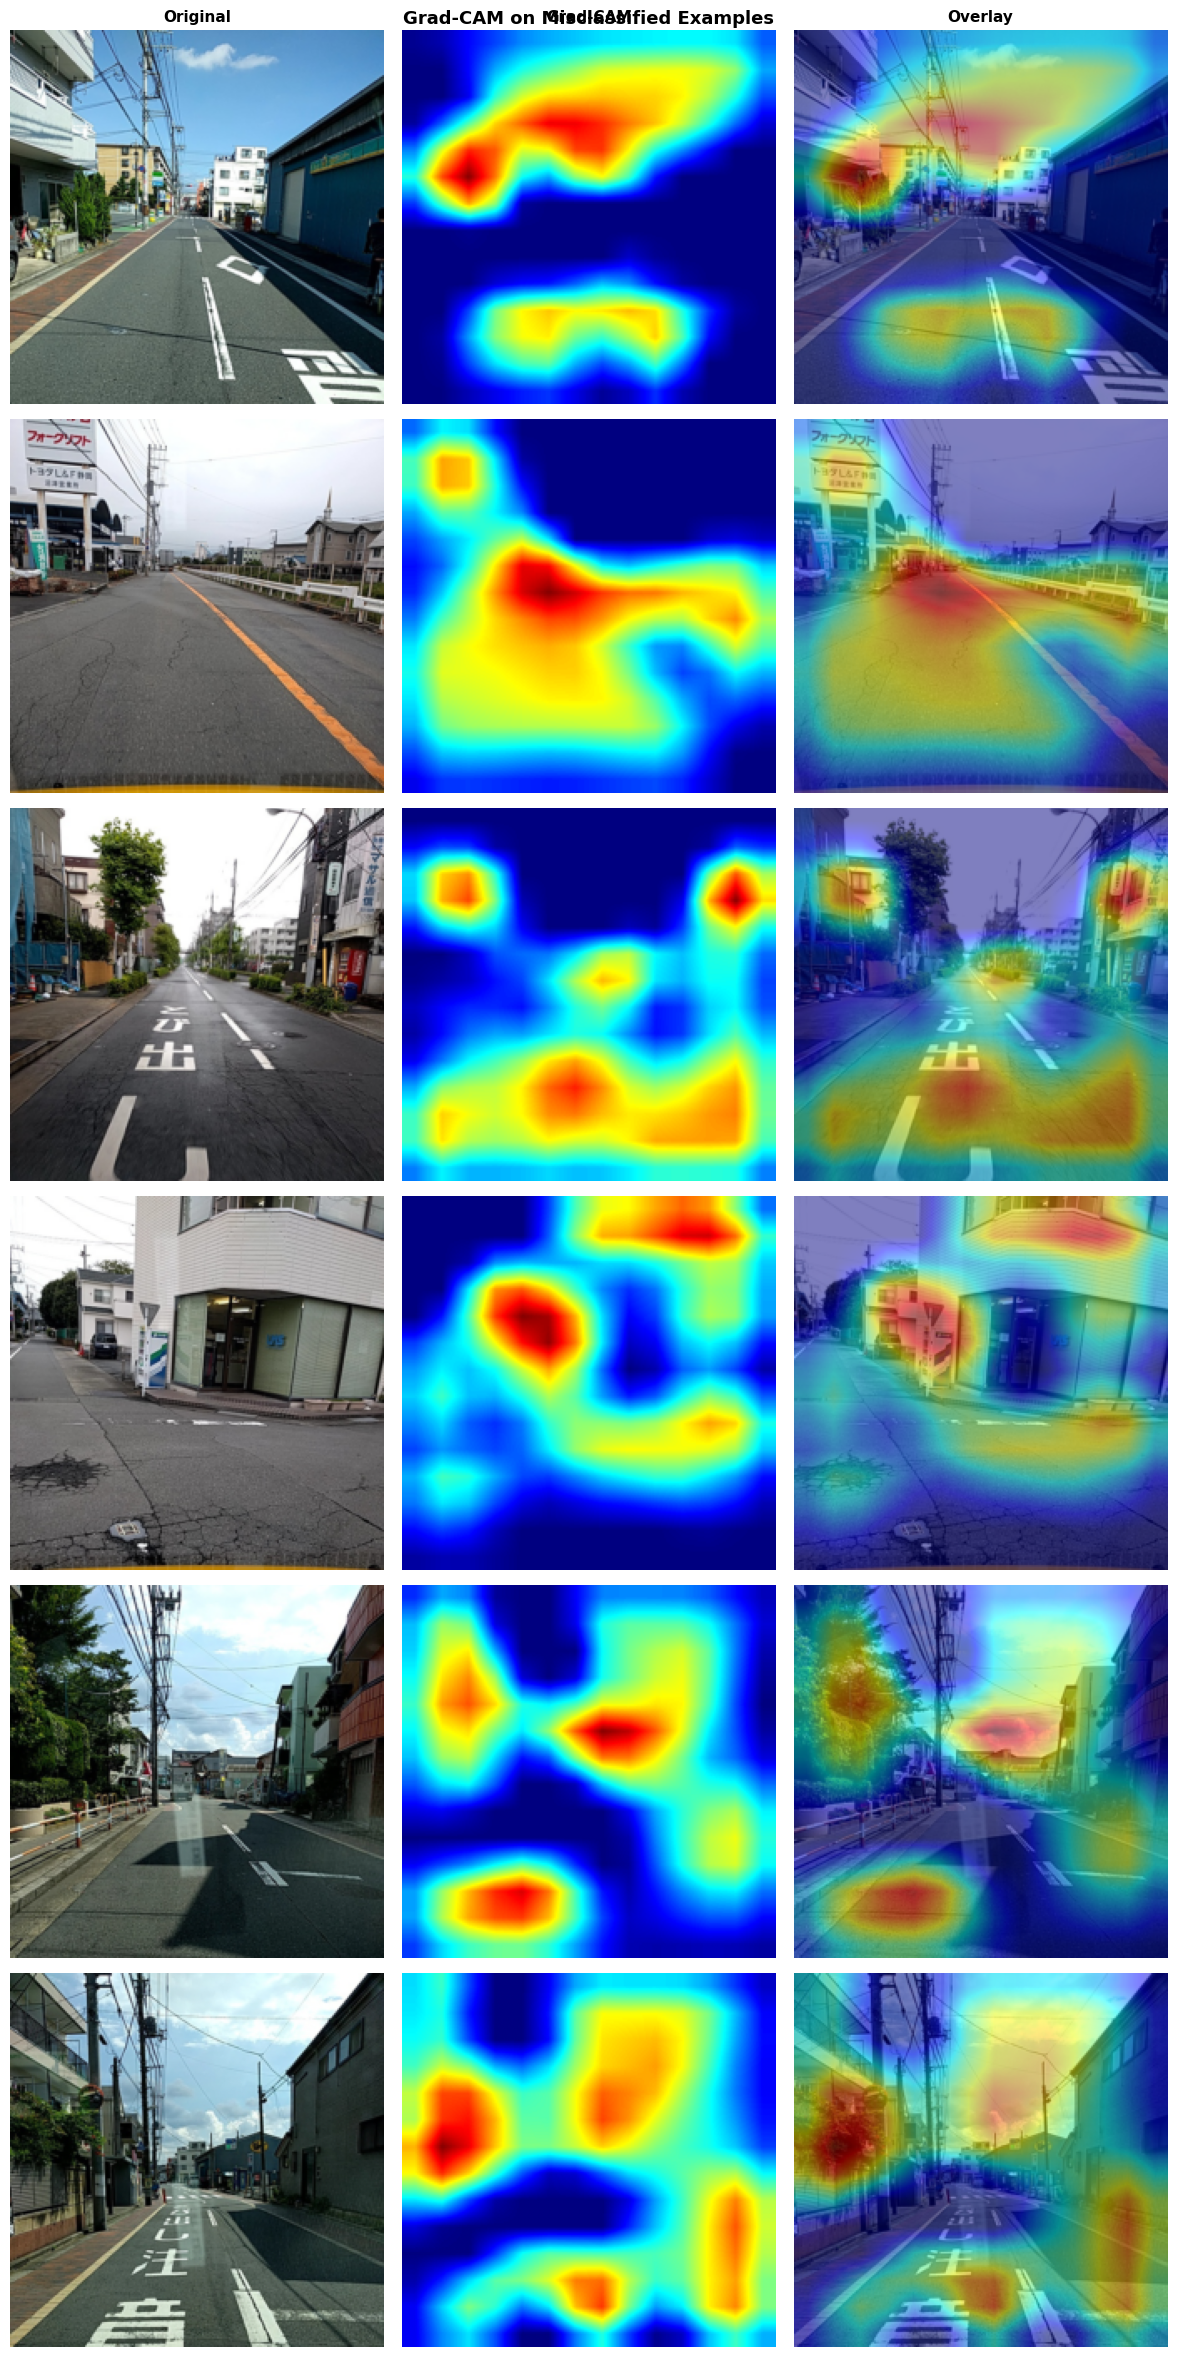

In [18]:
wrong_indices = np.where(all_preds != all_labels)[0]
print(f'Misclassified: {len(wrong_indices)} / {len(all_labels)}')

n_show = min(6, len(wrong_indices))
chosen = random.sample(list(wrong_indices), n_show)

fig, axes = plt.subplots(n_show, 3, figsize=(12, n_show * 4))
fig.suptitle('Grad-CAM on Misclassified Examples', fontsize=13, fontweight='bold')

for ax, t in zip(axes[0], ['Original', 'Grad-CAM', 'Overlay']):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row, idx in enumerate(chosen):
    img_tensor, _ = test_ds[idx]
    true_cls      = CLASS_NAMES[all_labels[idx]]
    pred_cls      = CLASS_NAMES[all_preds[idx]]

    # Generate CAM for the predicted (wrong) class to understand why the model was confused
    cam, _ = gradcam.generate(img_tensor, class_idx=int(all_preds[idx]))
    overlay, orig = overlay_gradcam(img_tensor, cam)

    heatmap_vis = cv2.resize(cam, (224, 224))
    heatmap_rgb = cv2.applyColorMap(np.uint8(255 * heatmap_vis), cv2.COLORMAP_JET)
    heatmap_rgb = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)

    axes[row][0].imshow(orig)
    axes[row][0].set_ylabel(f'True: {true_cls}\nPred: {pred_cls}',
                             fontsize=9, color='red', rotation=0,
                             labelpad=75, va='center')
    axes[row][1].imshow(heatmap_rgb)
    axes[row][2].imshow(overlay)

    for ax in axes[row]:
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/gradcam_misclassified.png', dpi=120, bbox_inches='tight')
plt.show()

Section 12 — Severity Index & Alert Analysis

Mean SI : 1.070
Max SI  : 3.000
Min SI  : 0.002
Mean Confidence: 0.9212
Priority distribution: {'MEDIUM': 87, 'HIGH': 46, 'LOW': 131, 'CRITICAL': 48}


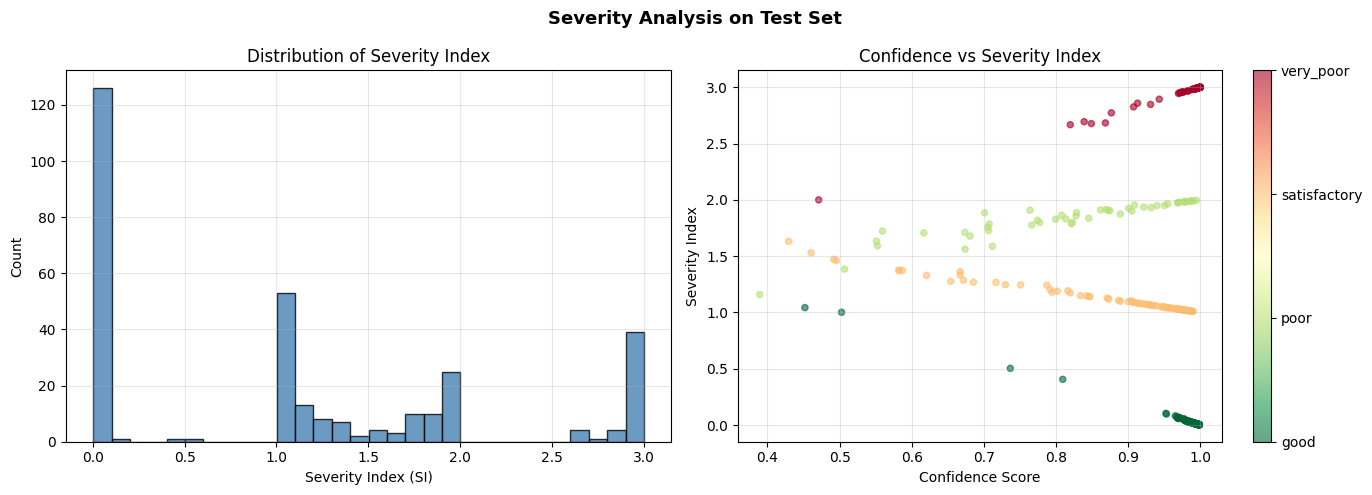

In [19]:
from collections import Counter

def compute_severity_metrics(probs_np):
    probs_t = torch.tensor(probs_np, dtype=torch.float32)

    # Argmax gives the predicted class, max gives the confidence for that class
    severity_labels   = probs_np.argmax(axis=1)
    confidence_scores = probs_np.max(axis=1)

    # Severity index is a weighted sum of class probabilities
    # It gives a continuous damage score rather than just a discrete label
    severity_indices  = (probs_t * SEVERITY_WEIGHTS).sum(dim=1).numpy()

    # Priority is derived from SI multiplied by confidence
    # High confidence in a high severity class yields CRITICAL priority
    def priority(si, conf):
        score = si * conf
        if score < 0.5:  return 'LOW'
        if score < 1.0:  return 'MEDIUM'
        if score < 2.0:  return 'HIGH'
        return 'CRITICAL'

    priority_levels = [priority(si, c)
                       for si, c in zip(severity_indices, confidence_scores)]
    return severity_labels, confidence_scores, severity_indices, priority_levels


sev_labels, conf_scores, sev_idx, priorities = compute_severity_metrics(all_probs)

print(f'Mean SI : {sev_idx.mean():.3f}')
print(f'Max SI  : {sev_idx.max():.3f}')
print(f'Min SI  : {sev_idx.min():.3f}')
print(f'Mean Confidence: {conf_scores.mean():.4f}')
print('Priority distribution:', dict(Counter(priorities)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Severity Analysis on Test Set', fontsize=13, fontweight='bold')

# Histogram shows how severity is distributed across the test set
axes[0].hist(sev_idx, bins=30, edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Severity Index (SI)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Severity Index')
axes[0].grid(alpha=0.3)

# Scatter plot shows the relationship between model confidence and damage severity
sc = axes[1].scatter(conf_scores, sev_idx,
                     c=sev_labels, cmap='RdYlGn_r', alpha=0.6, s=20)
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('Severity Index')
axes[1].set_title('Confidence vs Severity Index')
axes[1].grid(alpha=0.3)
cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_ticks(range(NUM_CLASSES))
cbar.set_ticklabels(CLASS_NAMES)

plt.tight_layout()
plt.savefig('/content/severity_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

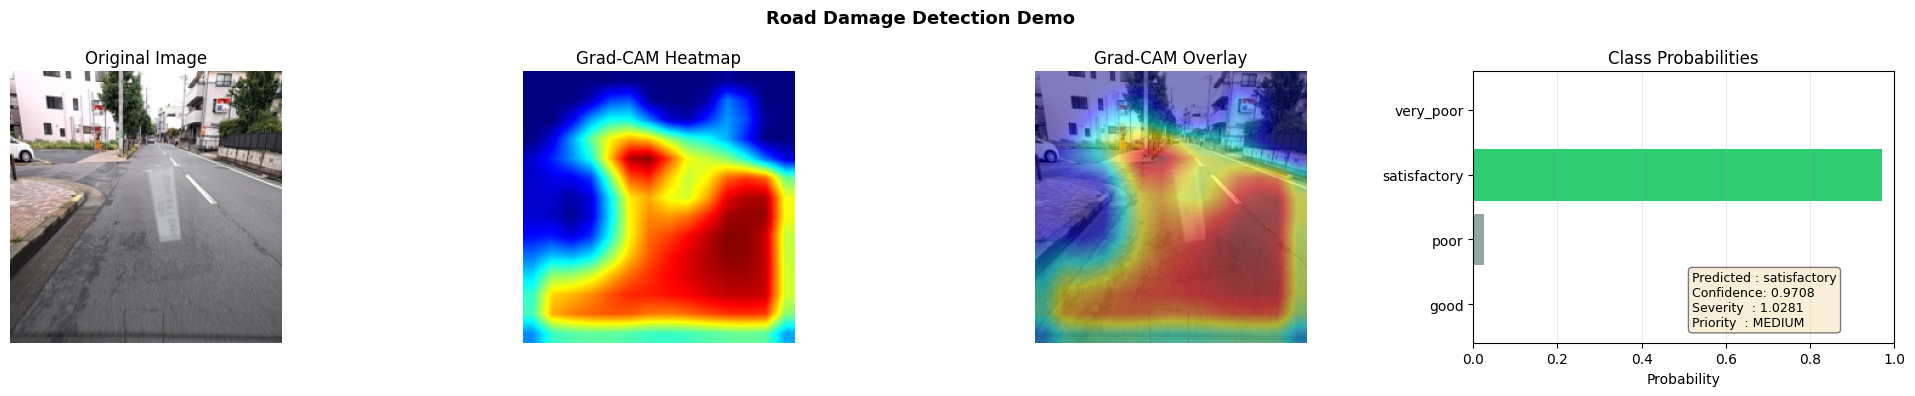

Result     : {'predicted_class': 'satisfactory', 'confidence': 0.9708, 'severity_index': 1.0281, 'maintenance_priority': 'MEDIUM', 'class_probabilities': {'good': 0.0014, 'poor': 0.0262, 'satisfactory': 0.9708, 'very_poor': 0.0017}}
True label : satisfactory


In [20]:
def predict_and_explain(image_path):
    img    = Image.open(image_path).convert('RGB')
    tensor = val_tf(img)

    # Run forward pass to get class probabilities
    model.eval()
    with torch.no_grad():
        logits = model(tensor.unsqueeze(0).to(DEVICE))
        probs  = F.softmax(logits, dim=1).cpu().squeeze(0)

    pred_idx   = probs.argmax().item()
    confidence = probs.max().item()
    si         = (probs * SEVERITY_WEIGHTS).sum().item()
    pred_class = CLASS_NAMES[pred_idx]

    # Determine maintenance priority from combined SI and confidence score
    score    = si * confidence
    priority = ('LOW'      if score < 0.5 else
                'MEDIUM'   if score < 1.0 else
                'HIGH'     if score < 2.0 else 'CRITICAL')

    # Generate Grad-CAM heatmap to explain the prediction visually
    cam, _        = gradcam.generate(tensor, class_idx=pred_idx)
    overlay, orig = overlay_gradcam(tensor, cam)
    heatmap_vis   = cv2.resize(cam, (224, 224))
    heatmap_rgb   = cv2.applyColorMap(np.uint8(255 * heatmap_vis), cv2.COLORMAP_JET)
    heatmap_rgb   = cv2.cvtColor(heatmap_rgb, cv2.COLOR_BGR2RGB)

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    fig.suptitle('Road Damage Detection Demo', fontsize=13, fontweight='bold')

    axes[0].imshow(orig)
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(heatmap_rgb)
    axes[1].set_title('Grad-CAM Heatmap')
    axes[1].axis('off')

    axes[2].imshow(overlay)
    axes[2].set_title('Grad-CAM Overlay')
    axes[2].axis('off')

    # Bar chart of class probabilities with predicted class highlighted in green
    colors = ['#2ecc71' if c == pred_class else '#95a5a6' for c in CLASS_NAMES]
    axes[3].barh(CLASS_NAMES, probs.numpy(), color=colors)
    axes[3].set_xlim(0, 1)
    axes[3].set_xlabel('Probability')
    axes[3].set_title('Class Probabilities')
    axes[3].grid(axis='x', alpha=0.3)

    # Summary box with all key outputs in one place
    textstr = (f'Predicted : {pred_class}\n'
               f'Confidence: {confidence:.4f}\n'
               f'Severity  : {si:.4f}\n'
               f'Priority  : {priority}')
    axes[3].text(0.52, 0.05, textstr, transform=axes[3].transAxes,
                 fontsize=9, verticalalignment='bottom',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.savefig('/content/demo_inference.png', dpi=120, bbox_inches='tight')
    plt.show()

    return {
        'predicted_class'     : pred_class,
        'confidence'          : round(confidence, 4),
        'severity_index'      : round(si, 4),
        'maintenance_priority': priority,
        'class_probabilities' : {c: round(p.item(), 4)
                                 for c, p in zip(CLASS_NAMES, probs)}
    }

# Run the demo on the first test image
demo_path, demo_true = full_dataset.samples[idx_test[0]]
result = predict_and_explain(demo_path)
print('Result     :', result)
print('True label :', CLASS_NAMES[demo_true])

In [21]:
import shutil
from google.colab import files

# Copy checkpoint to a clearly named file in Colab storage
output_path = '/content/road_damage_test2_model.pth'
shutil.copy(CKPT_PATH, output_path)
print(f'Model saved to: {output_path}')

# This triggers a browser download directly to your local machine
files.download(output_path)
print('Download started.')

Model saved to: /content/road_damage_test2_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download started.
